<a href="https://colab.research.google.com/github/msrdjan/mat-2026-okruzno-3-razred/blob/main/rezultati-analiza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Okružno takmičenje iz matematike - 3. razred
## Beograd, 08.03.2026. - Analiza rezultata

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/msrdjan/mat-2026-okruzno-3-razred/blob/main/rezultati-analiza.ipynb)

Izvor podataka: [Preliminarni rezultati (PDF)](https://www.ilijabircanin.edu.rs/wp-content/uploads/2026/03/OkruznoTakmicenje-Rezultati-3.razred.pdf)

Takmičenje se sastoji od 5 zadataka, svaki nosi po 20 poena (ukupno 100).
Ovaj notebook analizira rezultate svih učenika koji su učestvovali na okružnom nivou.

In [16]:
!pip install -q pdfplumber matplotlib seaborn

import subprocess
import tempfile
import pdfplumber
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

PDF_URL = "https://www.ilijabircanin.edu.rs/wp-content/uploads/2026/03/OkruznoTakmicenje-Rezultati-3.razred.pdf"

with tempfile.NamedTemporaryFile(suffix=".pdf") as tmp:
    subprocess.run(["curl", "-sL", "-o", tmp.name, PDF_URL], check=True, timeout=30)

    all_rows = []
    with pdfplumber.open(tmp.name) as pdf:
        for page in pdf.pages:
            for table in page.extract_tables():
                for row in table:
                    if row and row[-1] and row[-1].strip().isdigit():
                        all_rows.append(row)

df = pd.DataFrame(all_rows, columns=[
    "Ime i prezime", "Nastavnica/Nastavnik", "Skola",
    "Z1", "Z2", "Z3", "Z4", "Z5", "Ukupno"
])
for col in ["Z1", "Z2", "Z3", "Z4", "Z5", "Ukupno"]:
    df[col] = df[col].astype(int)

df = df.sort_values("Ukupno", ascending=False).reset_index(drop=True)
df["Rang"] = df.index + 1

task_cols = ["Z1", "Z2", "Z3", "Z4", "Z5"]

print(f"Broj ucenika: {len(df)}")

Broj ucenika: 153


## Prvih 10 učenika

In [17]:
top10 = df.head(10)[["Rang", "Ime i prezime", "Skola", "Z1", "Z2", "Z3", "Z4", "Z5", "Ukupno"]]
top10.style.hide(axis="index").set_caption("Top 10 učenika po ukupnom broju poena")

Rang,Ime i prezime,Skola,Z1,Z2,Z3,Z4,Z5,Ukupno
1,Коста Минић,Алекса Шантић,20,20,20,20,20,100
2,Лара Папић,Јелена Ћетковић,20,20,20,20,20,100
3,Ленка Чабаркапа,20.октобар,20,20,20,20,20,100
4,Игњат Узелац,Борислав Пекић,20,20,20,20,20,100
5,Стефан Секулић,Ђуро Стругар,20,20,20,20,20,100
6,Богдан Новокмет,Јован Стерија Поповић,20,20,20,20,20,100
7,Методије Марковић,Карађорђе - Чукарица,20,20,20,20,20,100
8,Ива Фетаховић,Ћирило и Методије,20,20,18,20,20,98
9,Филип Вељковић,Михајло Пупин,20,20,20,16,20,96
10,Момчило Јаковљевић,Борислав Пекић,20,20,20,16,20,96


## Distribucija rezultata

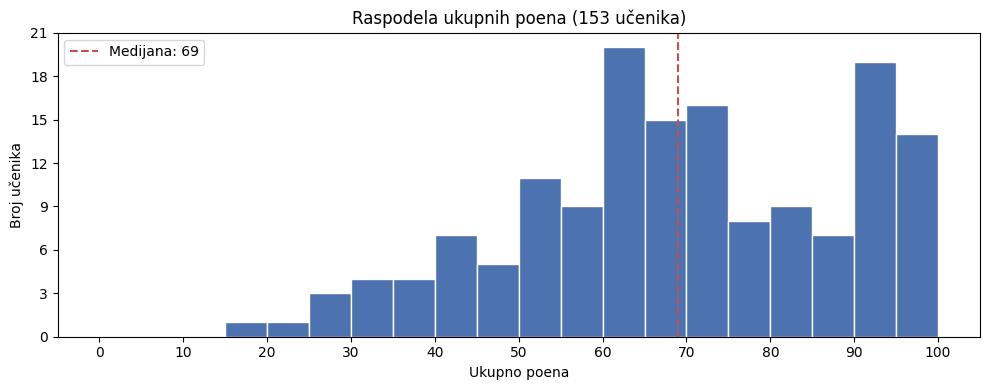

Prosek: 68.2 | Medijana: 69 | Min: 16 | Max: 100


In [18]:
fig, ax = plt.subplots(figsize=(10, 4))

bins = range(0, 105, 5)
counts, edges, patches = ax.hist(df["Ukupno"], bins=bins, edgecolor="white", color="#4C72B0")

ax.set_xlabel("Ukupno poena")
ax.set_ylabel("Broj učenika")
ax.set_title("Raspodela ukupnih poena (153 učenika)")
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

median = df["Ukupno"].median()
ax.axvline(median, color="#C44E52", linestyle="--", linewidth=1.5, label=f"Medijana: {median:.0f}")
ax.legend()

plt.tight_layout()
plt.show()

desc = df["Ukupno"].describe()
print(f"Prosek: {desc['mean']:.1f} | Medijana: {desc['50%']:.0f} | "
      f"Min: {desc['min']:.0f} | Max: {desc['max']:.0f}")

## Rang-lista po broju poena

Za svaki ostvareni rezultat: koliko učenika ga je postiglo i na kojim su pozicijama.

In [19]:
score_groups = df.groupby("Ukupno").agg(
    Ucenika=("Rang", "count"),
    Pozicija_od=("Rang", "min"),
    Pozicija_do=("Rang", "max"),
).sort_index(ascending=False).reset_index()

score_groups.columns = ["Poeni", "Broj učenika", "Pozicija od", "Pozicija do"]
score_groups["Pozicija"] = score_groups.apply(
    lambda r: str(r["Pozicija od"]) if r["Pozicija od"] == r["Pozicija do"]
    else f"{r['Pozicija od']}-{r['Pozicija do']}", axis=1
)

display_cols = score_groups[["Poeni", "Broj učenika", "Pozicija"]].copy()
display_cols.index = range(1, len(display_cols) + 1)
display_cols.index.name = "#"

display_cols.style.set_caption(
    f"Raspodela rezultata ({len(score_groups)} različitih vrednosti, {len(df)} učenika)"
)

,Poeni,Broj učenika,Pozicija
#,,,
1,100,7,1-7
2,98,1,8
3,96,3,9-11
4,95,3,12-14
5,92,15,15-29
6,90,4,30-33
7,87,2,34-35
8,86,5,36-40
9,84,1,41


## Najbolje škole (po proseku, minimum 2 učenika)

In [20]:
school_stats = (
    df.groupby("Skola")
    .agg(Ucenika=("Ukupno", "count"), Prosek=("Ukupno", "mean"),
         Max=("Ukupno", "max"), Min=("Ukupno", "min"))
    .query("Ucenika >= 2")
    .sort_values("Prosek", ascending=False)
)
school_stats["Prosek"] = school_stats["Prosek"].round(1)
school_stats = school_stats.reset_index()
school_stats.index = range(1, len(school_stats) + 1)
school_stats.index.name = "#"

school_stats.head(10).style.set_caption("Top 10 škola po prosečnom rezultatu")

,Skola,Ucenika,Prosek,Max,Min
#,,,,,
1,20.октобар,2,95.000000,100,90
2,Јелена Ћетковић,3,94.700000,100,92
3,Алекса Шантић,2,89.500000,100,79
4,Ћирило и Методије,6,81.800000,98,60
5,Јован Стерија Поповић,4,81.200000,100,63
6,Ђуро Стругар,6,80.000000,100,54
7,Михајло Пупин,3,79.300000,96,52
8,Павле Савић,6,77.500000,92,57
9,Милан Ракић,3,76.300000,95,52


## Najbolji nastavnici (po proseku, minimum 2 učenika)

In [21]:
teacher_stats = (
    df.groupby("Nastavnica/Nastavnik")
    .agg(Ucenika=("Ukupno", "count"), Prosek=("Ukupno", "mean"),
         Rezultati=("Ukupno", lambda x: sorted(x.tolist(), reverse=True)))
    .query("Ucenika >= 2")
    .sort_values("Prosek", ascending=False)
)
teacher_stats["Prosek"] = teacher_stats["Prosek"].round(1)
teacher_stats = teacher_stats.reset_index()
teacher_stats.index = range(1, len(teacher_stats) + 1)
teacher_stats.index.name = "#"

teacher_stats.head(10).style.set_caption("Top 10 nastavnika po prosečnom rezultatu")

,Nastavnica/Nastavnik,Ucenika,Prosek,Rezultati
#,,,,
1,Јован Мијаиловић,2,96.000000,"[100, 92]"
2,Данило Милинковић,2,94.000000,"[96, 92]"
3,Јована Крнета,2,93.000000,"[96, 90]"
4,Младенка Башић,2,91.000000,"[96, 86]"
5,Јасмина Пита Михајловић,4,87.800000,"[98, 87, 86, 80]"
6,Јована Јаковљевић,2,86.000000,"[100, 72]"
7,Наталија Дрча,3,85.000000,"[100, 92, 63]"
8,Тијана Братић,2,83.000000,"[92, 74]"
9,Биљана Стошић,3,80.300000,"[100, 79, 62]"


## Uspešnost po zadacima

Koji zadaci su bili najlakši, a koji najteži?

,Prosek,Medijana,Min,Max,Max. 20 poena (%)
Zadatak 1,16.100000,20.000000,0.000000,20.000000,80%
Zadatak 2,18.200000,20.000000,0.000000,20.000000,91%
Zadatak 3,11.800000,18.000000,0.000000,20.000000,59%
Zadatak 4,10.700000,12.000000,0.000000,20.000000,53%
Zadatak 5,11.300000,15.000000,0.000000,20.000000,57%


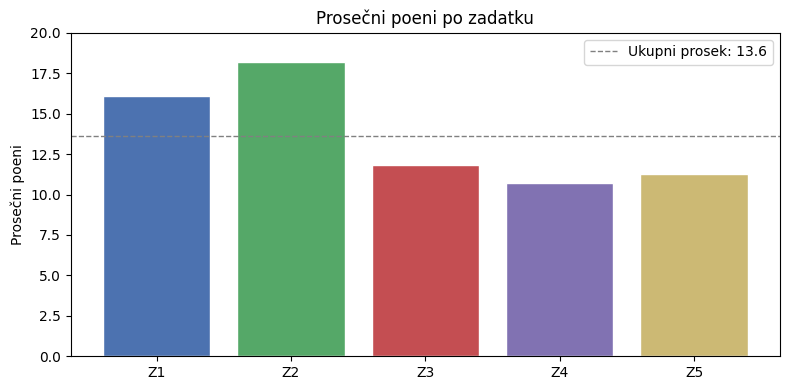

In [22]:
task_stats = df[task_cols].describe().loc[["mean", "50%", "min", "max"]].T
task_stats.columns = ["Prosek", "Medijana", "Min", "Max"]
task_stats["Prosek"] = task_stats["Prosek"].round(1)
task_stats.index = [f"Zadatak {i+1}" for i in range(5)]
task_stats["Max. 20 poena (%)"] = (task_stats["Prosek"] / 20 * 100).round(0).astype(int).astype(str) + "%"

display(task_stats.style.set_caption("Statistika po zadacima (max 20 poena svaki)"))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"]
ax.bar([f"Z{i+1}" for i in range(5)], task_stats["Prosek"], color=colors, edgecolor="white")
ax.set_ylabel("Prosečni poeni")
ax.set_title("Prosečni poeni po zadatku")
ax.set_ylim(0, 20)
ax.axhline(y=df[task_cols].values.mean(), color="gray", linestyle="--", linewidth=1,
           label=f"Ukupni prosek: {df[task_cols].values.mean():.1f}")
ax.legend()
plt.tight_layout()
plt.show()

## Percentili: "Gde se nalazi moje dete?"

Kriva kumulativne distribucije (CDF): za bilo koji broj poena, očitajte koji procenat učenika ima manji rezultat. Npr. ako je vaše dete osvojilo 80 poena, ono je bolje od ~80% ucenika.

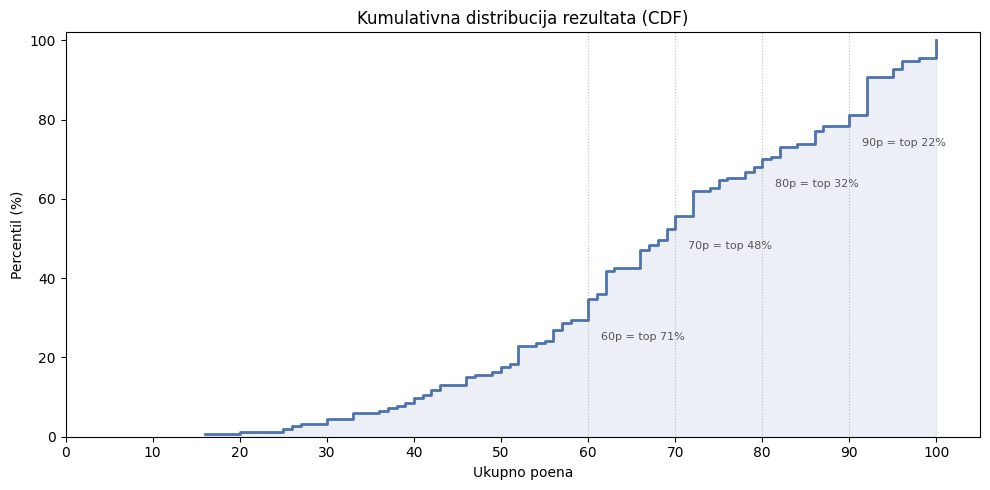

In [23]:
sorted_scores = np.sort(df["Ukupno"])
cdf = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores) * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.step(sorted_scores, cdf, where="post", color="#4C72B0", linewidth=2)
ax.fill_between(sorted_scores, cdf, step="post", alpha=0.1, color="#4C72B0")

for threshold in [60, 70, 80, 90]:
    pct = (df["Ukupno"] < threshold).sum() / len(df) * 100
    ax.axvline(threshold, color="gray", linestyle=":", linewidth=0.8, alpha=0.5)
    ax.annotate(f"{threshold}p = top {100-pct:.0f}%",
                xy=(threshold, pct), xytext=(threshold + 1.5, pct - 5),
                fontsize=8, color="#555")

ax.set_xlabel("Ukupno poena")
ax.set_ylabel("Percentil (%)")
ax.set_title("Kumulativna distribucija rezultata (CDF)")
ax.set_xlim(0, 105)
ax.set_ylim(0, 102)
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
plt.tight_layout()
plt.show()

## Distribucija poena po zadatku

Violin plot prikazuje kompletnu raspodelu za svaki zadatak: šire područje znaci više učenika sa tim brojem poena. Beli krug oznacava medijanu, deblja linija interkvartilni raspon. Korisno za uočavanje "sve ili ništa" zadataka (npr. Z2 gde je 88% učenika imalo maksimalan broj poena).

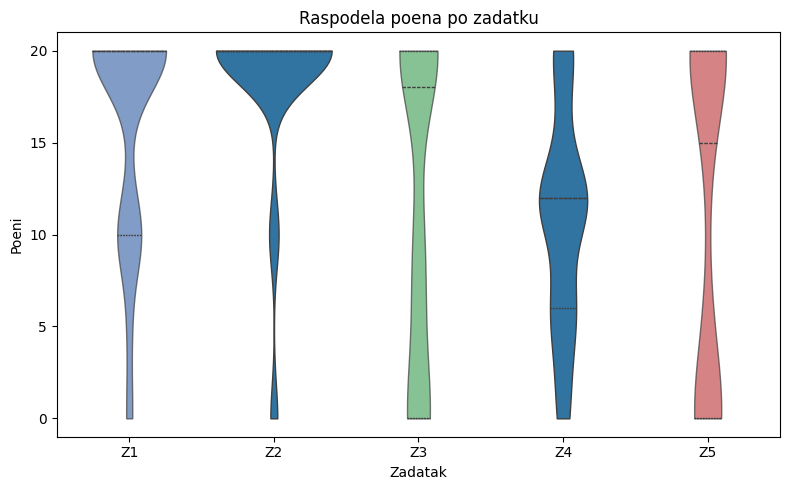

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"]

task_data = pd.melt(df[task_cols], var_name="Zadatak", value_name="Poeni")
parts = sns.violinplot(data=task_data, x="Zadatak", y="Poeni", ax=ax,
                       inner="quartile", cut=0, linewidth=1)

for i, body in enumerate(parts.collections[::2]):
    body.set_facecolor(colors[i % len(colors)])
    body.set_alpha(0.7)

ax.set_ylabel("Poeni")
ax.set_title("Raspodela poena po zadatku")
ax.set_ylim(-1, 21)
ax.yaxis.set_major_locator(ticker.MultipleLocator(5))
plt.tight_layout()
plt.show()

## Analiza zadataka: težina i diskriminativnost

Standardna analiza kvaliteta zadataka iz obrazovne statistike:
- **Težina** = prosek / max (0.0-1.0, niže = teže)
- **Diskriminativnost** = razlika proseka najjačih 27% i najslabijih 27%, podeljena sa max. Vrednosti iznad 0.3 znače da zadatak dobro razdvaja učenike.
- **20/20** i **0** = procenat učenika sa maksimalnim, odnosno nula poena.

In [25]:
n = len(df)
n27 = int(n * 0.27)
top27 = df.head(n27)
bot27 = df.tail(n27)

item_analysis = pd.DataFrame(index=[f"Zadatak {i+1}" for i in range(5)])
item_analysis["Prosek"] = [df[c].mean().round(1) for c in task_cols]
item_analysis["Tezina"] = [round(df[c].mean() / 20, 2) for c in task_cols]
item_analysis["Diskriminativnost"] = [
    round((top27[c].mean() - bot27[c].mean()) / 20, 2) for c in task_cols
]
item_analysis["20/20 (%)"] = [f"{(df[c] == 20).sum() / n * 100:.0f}%" for c in task_cols]
item_analysis["0 poena (%)"] = [f"{(df[c] == 0).sum() / n * 100:.0f}%" for c in task_cols]

def color_disc(val):
    if isinstance(val, (int, float)):
        if val >= 0.3:
            return "background-color: #d4edda"
        elif val >= 0.2:
            return "background-color: #fff3cd"
        else:
            return "background-color: #f8d7da"
    return ""

item_analysis.style.map(color_disc, subset=["Diskriminativnost"]).set_caption(
    "Analiza kvaliteta zadataka (zeleno: dobra diskriminativnost >= 0.3)"
)

,Prosek,Tezina,Diskriminativnost,20/20 (%),0 poena (%)
Zadatak 1,16.100000,0.810000,0.330000,67%,5%
Zadatak 2,18.200000,0.910000,0.170000,88%,5%
Zadatak 3,11.800000,0.590000,0.790000,48%,28%
Zadatak 4,10.700000,0.540000,0.430000,16%,8%
Zadatak 5,11.300000,0.570000,0.760000,48%,35%


## Sastav rezultata, prvih 50 učenika

Horizontalni slagani grafikon pokazuje od kojih zadataka se sastoji ukupni rezultat svakog učenika. Odmah se vidi gde su izgubljeni poeni i da li su svi učenici "pali" na istom zadatku.

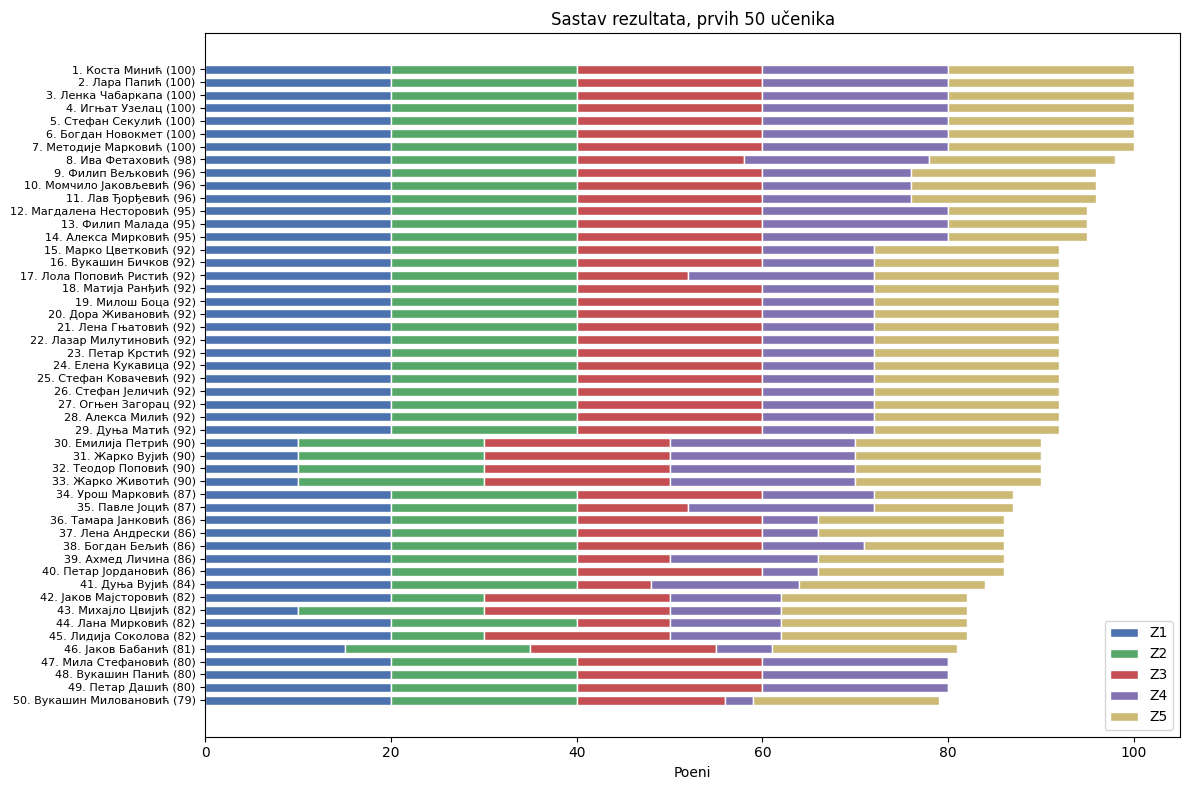

In [26]:
top_n = 50
top = df.head(top_n).copy()
labels = [f"{r['Rang']}. {r['Ime i prezime']} ({r['Ukupno']})" for _, r in top.iterrows()]

fig, ax = plt.subplots(figsize=(12, 8))
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"]
y_pos = range(top_n)

left = np.zeros(top_n)
for i, col in enumerate(task_cols):
    vals = top[col].values
    ax.barh(y_pos, vals, left=left, color=colors[i], label=f"Z{i+1}", edgecolor="white", height=0.7)
    left += vals

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Poeni")
ax.set_title(f"Sastav rezultata, prvih {top_n} učenika")
ax.legend(loc="lower right")
ax.set_xlim(0, 105)
plt.tight_layout()
plt.show()

## Korelacija između zadataka

Matrica korelacija pokazuje koliko su rezultati na različitim zadacima međusobno povezani. Visoka korelacija znači da zadaci mere slične veštine; niska korelacija znači da testiraju različite sposobnosti (što je poželjno za dobar test).

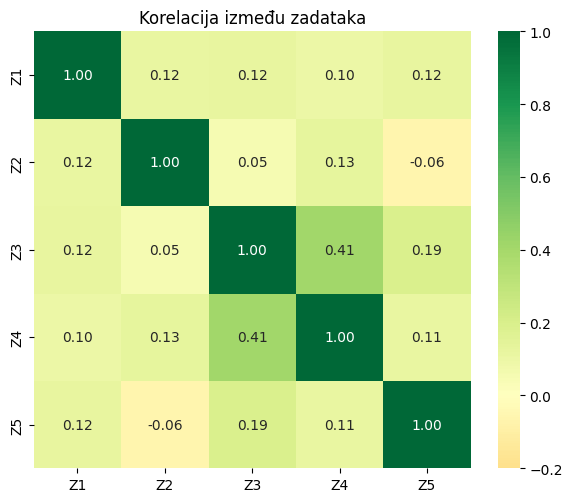

In [27]:
corr = df[task_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            vmin=-0.2, vmax=1, square=True,
            xticklabels=[f"Z{i+1}" for i in range(5)],
            yticklabels=[f"Z{i+1}" for i in range(5)], ax=ax)
ax.set_title("Korelacija između zadataka")
plt.tight_layout()
plt.show()

## Poređenje škola (box plot, minimum 3 učenika)

Prosek ne govori celu priču. Box plot za svaku školu prikazuje raspon rezultata. Škola sa visokim prosekom ali i velikim rasponom ima neujednačene učenike.

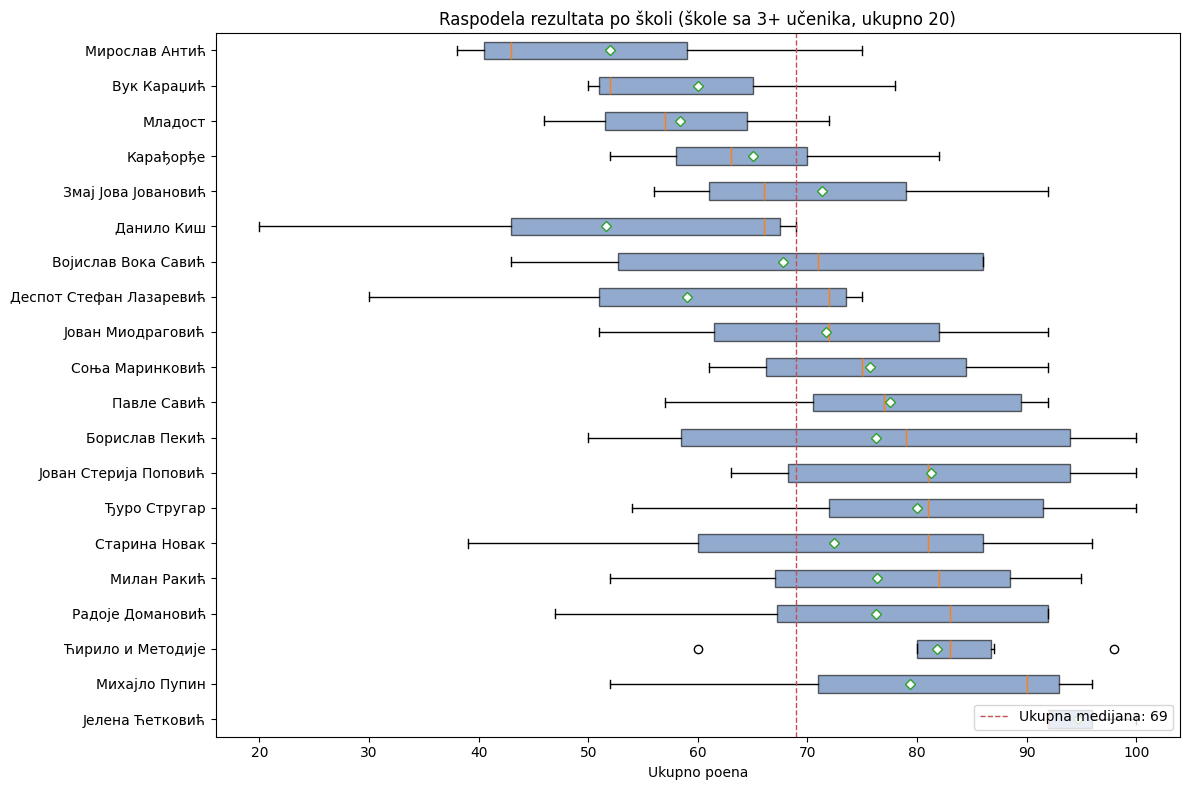

In [28]:
school_counts = df["Skola"].value_counts()
schools_3plus = school_counts[school_counts >= 3].index
df_schools = df[df["Skola"].isin(schools_3plus)].copy()

school_order = df_schools.groupby("Skola")["Ukupno"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(12, max(6, len(school_order) * 0.4)))
bp = ax.boxplot([df_schools[df_schools["Skola"] == s]["Ukupno"] for s in school_order],
                tick_labels=school_order, vert=False, patch_artist=True, showmeans=True,
                meanprops=dict(marker="D", markerfacecolor="white", markersize=5))

for patch in bp["boxes"]:
    patch.set_facecolor("#4C72B0")
    patch.set_alpha(0.6)

ax.set_xlabel("Ukupno poena")
ax.set_title(f"Raspodela rezultata po školi (škole sa 3+ učenika, ukupno {len(school_order)})")
ax.axvline(df["Ukupno"].median(), color="#C44E52", linestyle="--", linewidth=1,
           label=f"Ukupna medijana: {df['Ukupno'].median():.0f}")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Tabela percentila

Referentna tabela: za svaki rezultat koji se pojavio na takmičenju, koliki je percentil (procenat učenika sa manjim rezultatom). Pronađite rezultat vašeg deteta i pročitajte percentil.

In [29]:
pct_table = df.groupby("Ukupno").agg(
    Ucenika=("Rang", "count"),
    Pozicija=("Rang", "min"),
).sort_index(ascending=False)

pct_table["Percentil"] = pct_table.index.map(
    lambda score: round((df["Ukupno"] < score).sum() / len(df) * 100, 1)
)
pct_table["Top %"] = (100 - pct_table["Percentil"]).round(1)

pct_display = pct_table.reset_index()
pct_display.columns = ["Poeni", "Broj učenika", "Najbolja pozicija", "Percentil", "Top %"]

def color_top(val):
    if isinstance(val, (int, float)):
        if val <= 5:
            return "background-color: #d4edda; font-weight: bold"
        elif val <= 10:
            return "background-color: #d4edda"
        elif val <= 25:
            return "background-color: #fff3cd"
    return ""

pct_display.style.hide(axis="index").map(color_top, subset=["Top %"]).set_caption(
    "Percentili (zeleno = top 10%, žuto = top 25%)"
)

Poeni,Broj učenika,Najbolja pozicija,Percentil,Top %
100,7,1,95.400000,4.600000
98,1,8,94.800000,5.200000
96,3,9,92.800000,7.200000
95,3,12,90.800000,9.200000
92,15,15,81.000000,19.000000
90,4,30,78.400000,21.600000
87,2,34,77.100000,22.900000
86,5,36,73.900000,26.100000
84,1,41,73.200000,26.800000
82,4,42,70.600000,29.400000


## Kompletna rang-lista

Svi rezultati sortirani od najboljeg ka najgorem.

In [30]:
full_list = df[["Rang", "Ime i prezime", "Skola", "Nastavnica/Nastavnik", "Z1", "Z2", "Z3", "Z4", "Z5", "Ukupno"]]

def highlight_top(row):
    if row["Ukupno"] >= 90:
        return ["background-color: #d4edda"] * len(row)
    elif row["Ukupno"] >= 80:
        return ["background-color: #fff3cd"] * len(row)
    return [""] * len(row)

full_list.style.apply(highlight_top, axis=1).hide(axis="index").set_caption(
    "Kompletna rang-lista (zeleno >= 90, žuto >= 80)"
)

Rang,Ime i prezime,Skola,Nastavnica/Nastavnik,Z1,Z2,Z3,Z4,Z5,Ukupno
1,Коста Минић,Алекса Шантић,Јасмина Ђурђевић,20,20,20,20,20,100
2,Лара Папић,Јелена Ћетковић,Јован Мијаиловић,20,20,20,20,20,100
3,Ленка Чабаркапа,20.октобар,Татјана Бошковић,20,20,20,20,20,100
4,Игњат Узелац,Борислав Пекић,Биљана Стошић,20,20,20,20,20,100
5,Стефан Секулић,Ђуро Стругар,Јована Јаковљевић,20,20,20,20,20,100
6,Богдан Новокмет,Јован Стерија Поповић,Наталија Дрча,20,20,20,20,20,100
7,Методије Марковић,Карађорђе - Чукарица,Љиљана Сушић,20,20,20,20,20,100
8,Ива Фетаховић,Ћирило и Методије,Јасмина Пита Михајловић,20,20,18,20,20,98
9,Филип Вељковић,Михајло Пупин,Јована Крнета,20,20,20,16,20,96
10,Момчило Јаковљевић,Борислав Пекић,Данило Милинковић,20,20,20,16,20,96
